Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Paper_Cutting_lora_weights.safetensors:   0%|          | 0.00/359M [00:00<?, ?B/s]

No LoRA keys associated to UNet2DConditionModel found with the prefix='unet'. This is safe to ignore if LoRA state dict didn't originally have any UNet2DConditionModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion/pipeline_stable_diffusion.py:897: FutureWarning: `callback` is deprecated and will be removed in version 1.0.0. Passing `callback` as an input argument to `__call__` is deprecated, consider using `callback_on_step_e

starting of generation...


  0%|          | 0/20 [00:00<?, ?it/s]

Step 1. Current value of noise: 0.0045
Step 2. Current value of noise: 0.0064
Step 3. Current value of noise: 0.0050
Step 4. Current value of noise: 0.0065
Step 5. Current value of noise: 0.0090
Step 6. Current value of noise: 0.0074
Step 7. Current value of noise: 0.0117
Step 8. Current value of noise: 0.0123
Step 9. Current value of noise: 0.0145
Step 10. Current value of noise: 0.0167
Step 11. Current value of noise: 0.0185
Step 12. Current value of noise: 0.0205
Step 13. Current value of noise: 0.0223
Step 14. Current value of noise: 0.0240
Step 15. Current value of noise: 0.0255
Step 16. Current value of noise: 0.0268
Step 17. Current value of noise: 0.0279
Step 18. Current value of noise: 0.0288
Step 19. Current value of noise: 0.0294
Step 20. Current value of noise: 0.0294


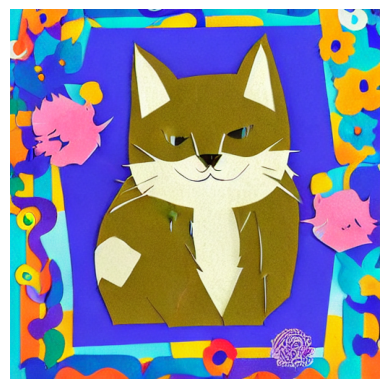

Finished!


In [ ]:
from diffusers import StableDiffusionPipeline
import torch
import matplotlib.pyplot as plt

# LoRA (Low-Rank Adaptation) is a fine-tuning technique that injects small, trainable rank-decomposition matrices into each layer of the Transformer architecture.
# Unlike full fine-tuning, LoRA allows you to drastically change the model's artistic style or add specific characters while keeping the main model weights frozen and the file size very small (megabytes instead of gigabytes).

# select model
model_id = "runwayml/stable-diffusion-v1-5"

# load pipeline
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float32).to("cpu")

#Load LoRA Weights "Paper_Cutting"
pipe.load_lora_weights("Kontext-Style/Paper_Cutting_lora", weight_name="Paper_Cutting_lora_weights.safetensors")

# use CPU
device = "cpu"
pipe = pipe.to(device)

# our prompt for CLIP
# we add "papercut style" to the prompt to trigger the LoRA features
prompt = "a cute fluffy cat, Paper_Cutting style, vibrant colors, soft studio lighting, high detail"


# function-callback which call in each step of scheduler
def latents_callback(step, timestamp, latents):
  print(f"Step {step}. Current value of noise: {latents.mean().item():.4f}")

# generation
print("starting of generation...")


result_image = pipe(
    prompt=prompt,
    num_inference_steps=20, # num_inference_steps - scheduler for U-Net
    guidance_scale=7.5,
    callback=latents_callback,
    callback_steps=1 # call 'latents_callback' each step
).images[0]

result_image.save("lora_papercut_cat.png")

plt.imshow(result_image)
plt.axis("off")
plt.show()

print("Finished!")
